# Projekt — Analýza CGM glykémie

**Autor:** Mgr. Dana Kozáková

---

## Kontext

Dáta pochádzajú z **iDCL Trial** (Breton et al., 2021; NCT03563313) — 6-mesačný randomizovaný trial porovnávajúci uzavretý okruh (**Control-IQ / CLC**) s bežnou senzorovou pumpou (SAP) u 168 pacientov s diabetom.

**Kľúčové zistenia paperu:**
- TIR (Time In Range 70–180 mg/dL) sa **celkovo nezlepšilo** po úprave parametrov pumpy (71.2% → 71.3%)
- **Ale u pacientov s vysokým HbA1c** sa zlepšenie prejavilo (51.2% → 57.7%)
- Parametre pumpy boli optimalizované v **týždni 0, 2 a 13**

**Cieľ:** Vybrala som pacienta s vyššou priemernou glykémiou a analyzujem jeho CGM profil — predikciu, sezónnosť, štrukturálne zlomy, volatilitu a kauzálne vzťahy. Chcem overiť, či sa zmenili parametre po zásahoch

**Vstup:** `data_patient_selected.csv` (výstup z `01_select_patient.ipynb`)

**Repozitár:** 

https://repository.niddk.nih.gov/study/292

https://public.jaeb.org/dataset/573

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.regression.recursive_ls import RecursiveLS
from statsmodels.tsa.api import VAR
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

import pmdarima as pm
from arch import arch_model
import ruptures as rpt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11


C:\ProgramData\miniconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


In [2]:
import os
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/images', exist_ok=True)

In [3]:
DATA_PATH = 'outputs/data/data_patient_selected.csv'
OUT_DATA = 'outputs/data/' # OUTPUT DATA PATH
OUT_IMG = 'outputs/images/' # OUTPUT IMAGES PATH

## Načítanie dát

In [4]:
# Načítanie hodinového časového radu (výstup z 1. skriptu)
df = pd.read_csv(DATA_PATH, parse_dates=['date_hour'])
df = df.sort_values('date_hour').reset_index(drop=True)
df.head()

,date_hour,CGM_mmol,CGM_mgdl
0,2017-07-31 14:00:00,8.08,145.500000
1,2017-07-31 15:00:00,7.19,129.416667
2,2017-07-31 16:00:00,5.11,91.923077
3,2017-07-31 17:00:00,6.81,122.666667
4,2017-07-31 18:00:00,7.62,137.083333


In [5]:
# Načítanie metadát pacienta
patient_info = {}
with open(OUT_DATA + 'patient_info.txt', 'r', encoding='utf-8') as f:
    for line in f:
        key, val = line.strip().split('=', 1)
        patient_info[key] = val

PATIENT_ID = patient_info['patient_id']
T0 = pd.to_datetime(patient_info['date_start'])
T2 = pd.to_datetime(patient_info['t2'])
T13 = pd.to_datetime(patient_info['t13'])

In [6]:
# Časový rad ako numpy array
y = df['CGM_mmol'].values
dates = df['date_hour'].values

In [7]:
print(f'Pacient: {PATIENT_ID}')
print(f'Počet pozorovaní: {len(y)}')

print(f'\nObdobie: {df["date_hour"].min()} — {df["date_hour"].max()}')
print(f'Nastavenie - T2: {T2}')
print(f'Nastavenie - T13: {T13}')

print(f'\nPriemerná glykémia: {y.mean():.2f} mmol/l')

Pacient: 28
Počet pozorovaní: 4515

Obdobie: 2017-07-31 14:00:00 — 2018-02-04 16:00:00
Nastavenie - T2: 2017-08-14 00:00:00
Nastavenie - T13: 2017-10-23 00:00:00

Priemerná glykémia: 10.40 mmol/l


---

# Fáza 1: Exploratívna analýza a dekompozícia

Štruktúra dát — či má rad trend (zlepšuje sa kompenzácia?), akú sezónnosť má, kde sú intervenčné body.

### 1.1 Popisná štatistika

In [8]:
# Popisná štatistika
cgm_mgdl = df['CGM_mgdl'].values
cgm_mmol = df['CGM_mmol'].values

tir = np.mean((cgm_mgdl >= 70) & (cgm_mgdl <= 180)) * 100
tbr = np.mean(cgm_mgdl < 70) * 100
tar = np.mean(cgm_mgdl > 180) * 100
gmi = 3.31 + 0.02392 * np.mean(cgm_mgdl)

desc_stats = pd.DataFrame({
    'Metrika': ['Počet pozorovaní', 'Priemer (mmol/l)', 'Medián (mmol/l)', 
                'SD (mmol/l)', 'Min (mmol/l)', 'Max (mmol/l)',
                'CV (%)', 'GMI / est. HbA1c (%)', 
                'TIR 70–180 mg/dL (%)', 'TBR <70 mg/dL (%)', 'TAR >180 mg/dL (%)'],
    'Hodnota': [len(y), f'{cgm_mmol.mean():.2f}', f'{np.median(cgm_mmol):.2f}',
                f'{cgm_mmol.std():.2f}', f'{cgm_mmol.min():.2f}', f'{cgm_mmol.max():.2f}',
                f'{(cgm_mmol.std()/cgm_mmol.mean())*100:.1f}', f'{gmi:.2f}',
                f'{tir:.1f}', f'{tbr:.1f}', f'{tar:.1f}']
})
desc_stats

,Metrika,Hodnota
0,Počet pozorovaní,4515
1,Priemer (mmol/l),10.40
2,Medián (mmol/l),9.62
3,SD (mmol/l),3.52
4,Min (mmol/l),3.60
5,Max (mmol/l),22.16
6,CV (%),33.9
7,GMI / est. HbA1c (%),7.79
8,TIR 70–180 mg/dL (%),53.5
9,TBR <70 mg/dL (%),0.1


### 1.2 Vizualizácia časového radu

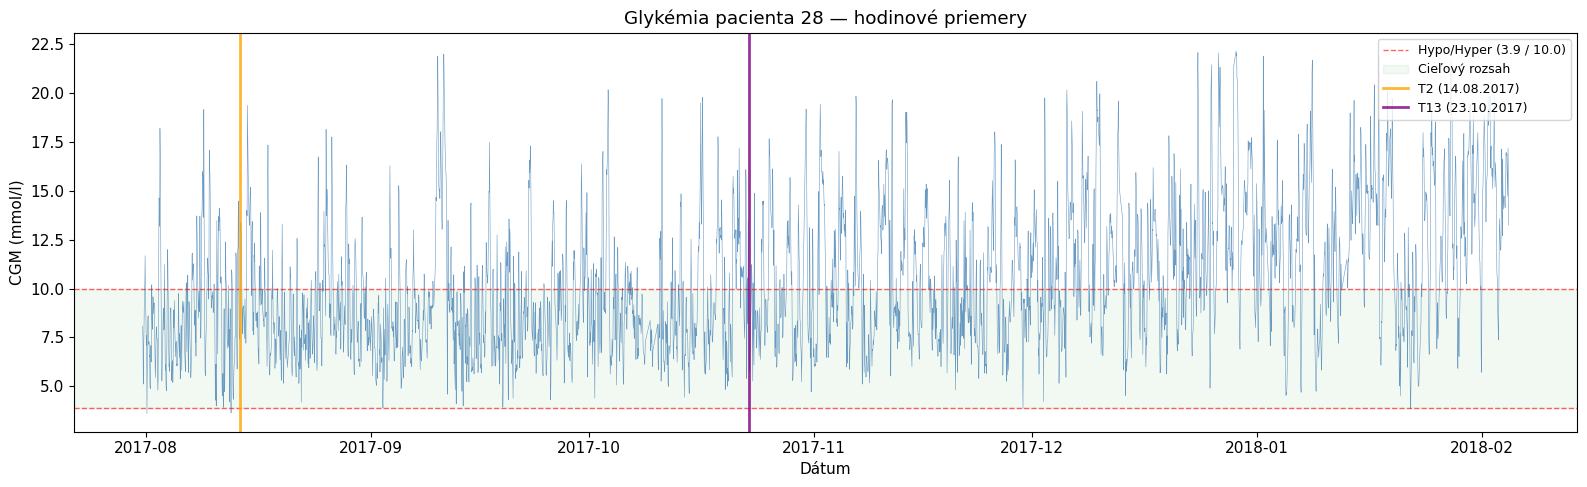

In [9]:
# Celý časový rad s vyznačenými intervenciami a referenčnými hranicami
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date_hour'], y, linewidth=0.4, color='steelblue', alpha=0.8)

# Referenčné hranice
ax.axhline(3.9, color='red', linestyle='--', lw=1, alpha=0.6, label='Hypo/Hyper (3.9 / 10.0)')
ax.axhline(10.0, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhspan(3.9, 10.0, alpha=0.05, color='green', label='Cieľový rozsah')

# Intervencie
ax.axvline(T2, color='orange', lw=2, alpha=0.8, label=f'T2 ({T2.strftime("%d.%m.%Y")})')
ax.axvline(T13, color='purple', lw=2, alpha=0.8, label=f'T13 ({T13.strftime("%d.%m.%Y")})')

ax.set_xlabel('Dátum')
ax.set_ylabel('CGM (mmol/l)')
ax.set_title(f'Glykémia pacienta {PATIENT_ID} — hodinové priemery')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()

plt.savefig(OUT_IMG + '01_timeseries_full.png', dpi=150, bbox_inches='tight')
plt.show()

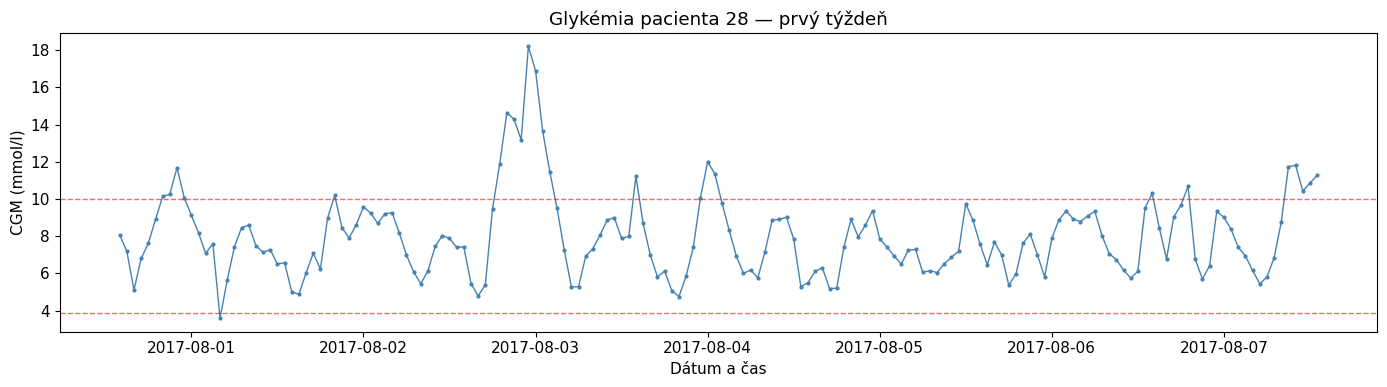

In [10]:
# Detail — prvý týždeň (168 hodín)
fig, ax = plt.subplots(figsize=(14, 4))
week1 = df.head(168)
ax.plot(week1['date_hour'], week1['CGM_mmol'], 'o-', markersize=2, linewidth=1, color='steelblue')
ax.axhline(3.9, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(10.0, color='red', linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel('Dátum a čas')
ax.set_ylabel('CGM (mmol/l)')
ax.set_title(f'Glykémia pacienta {PATIENT_ID} — prvý týždeň')
plt.tight_layout()
plt.savefig(OUT_IMG + '01_timeseries_week1.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 STL dekompozícia

STL (Seasonal and Trend decomposition using Loess) rozloží rad na trend, sezónnu zložku a reziduá. 

Na pochopenie, štruktúry dát. 

- je trend klesajúci?
- je 24h sezónnosť?

Výstup z STL informuje výber parametrov SARIMA — napríklad potvrdenie, že perióda s=24 má zmysel, že rad nevyžaduje diferencovanie (d=0), atď.

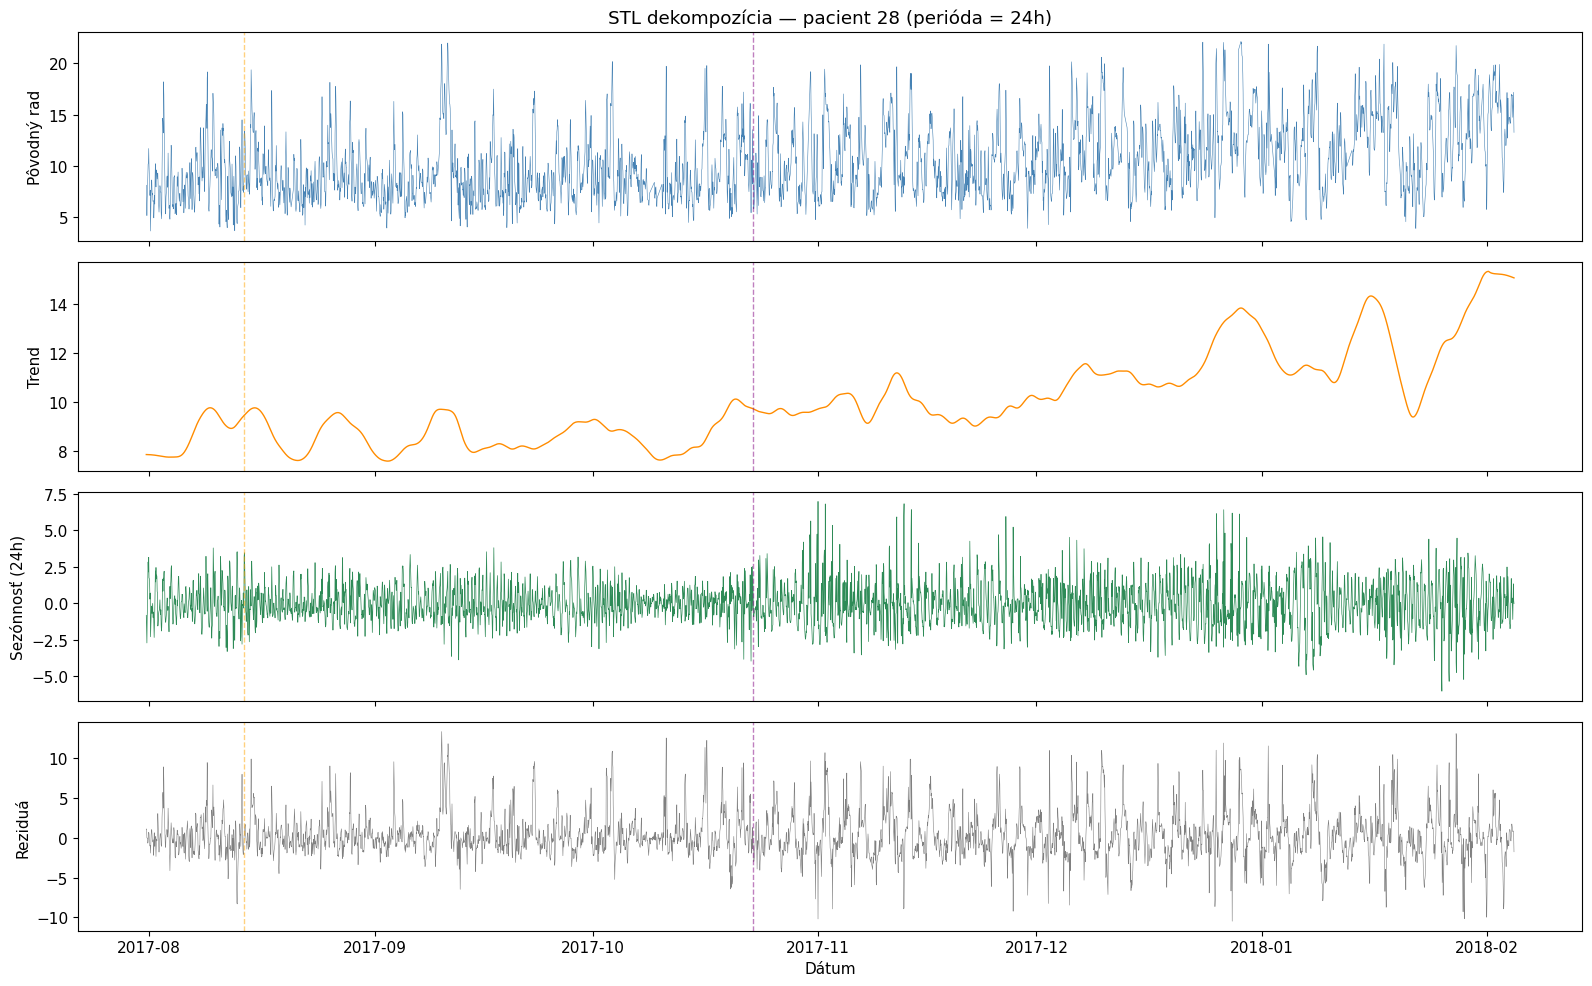

In [11]:
# STL dekompozícia s periódou 24 hodín
stl = STL(y, period=24, seasonal = 7, # priemerna glykemia v danu hodinu za cca 7 dni
          trend = 7*24+1, # pocet merani za cca 7 dni
          robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

axes[0].plot(dates, y, linewidth=0.4, color='steelblue')
axes[0].set_ylabel('Pôvodný rad')
axes[0].set_title(f'STL dekompozícia — pacient {PATIENT_ID} (perióda = 24h)')

axes[1].plot(dates, result.trend, linewidth=1, color='darkorange')
axes[1].set_ylabel('Trend')

axes[2].plot(dates, result.seasonal, linewidth=0.5, color='seagreen')
axes[2].set_ylabel('Sezónnosť (24h)')

axes[3].plot(dates, result.resid, linewidth=0.4, color='gray')
axes[3].set_ylabel('Reziduá')
axes[3].set_xlabel('Dátum')

# Vyznačenie intervencií
for ax in axes:
    ax.axvline(T2, color='orange', lw=1, alpha=0.5, linestyle='--')
    ax.axvline(T13, color='purple', lw=1, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(OUT_IMG + '01_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Denný profil

Vizualizácia priemernej glykémie podľa hodiny dňa ukáže prípadný 

- dawn phenomenon (ranný nárast) a
- dusk phenomenon (večerný nárast).

Toto je základ pre neskoršiu Grangerovu kauzalitu deň vs. noc.

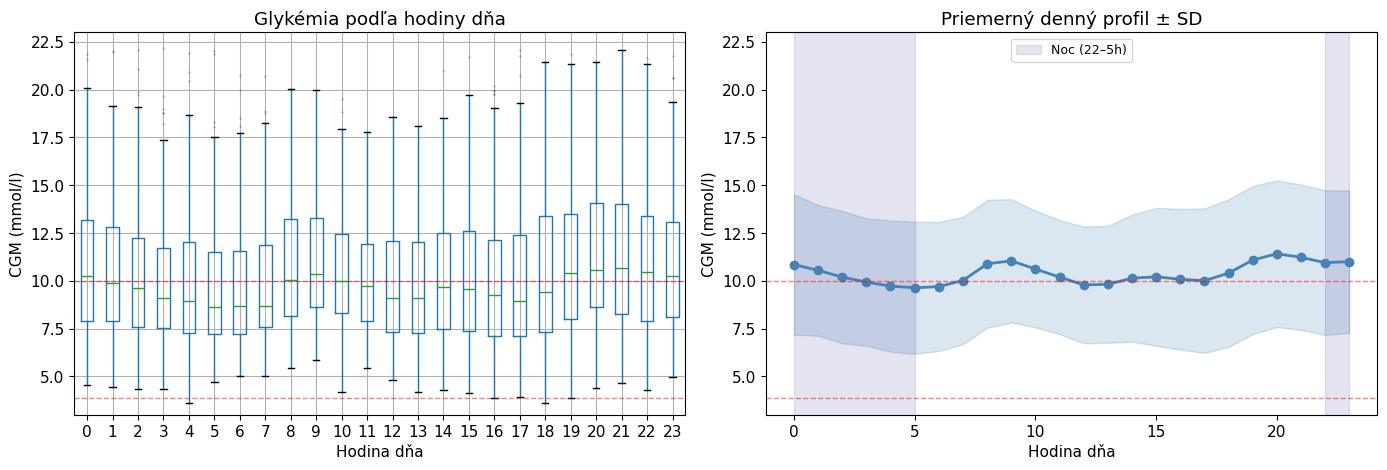

In [12]:
# Priemerný denný profil
df['hour'] = df['date_hour'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot podľa hodiny
df.boxplot(column='CGM_mmol', by='hour', ax=axes[0], 
           flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_ylim(3,23)
axes[0].set_xlabel('Hodina dňa')
axes[0].set_ylabel('CGM (mmol/l)')
axes[0].set_title('Glykémia podľa hodiny dňa')
axes[0].axhline(3.9, color='red', linestyle='--', lw=1, alpha=0.5)
axes[0].axhline(10.0, color='red', linestyle='--', lw=1, alpha=0.5)
plt.suptitle('')  

# Priemerný profil
hourly_profile = df.groupby('hour')['CGM_mmol'].agg(['mean', 'std'])
axes[1].plot(hourly_profile.index, hourly_profile['mean'], 'o-', color='steelblue', lw=2)
axes[1].fill_between(hourly_profile.index, 
                      hourly_profile['mean'] - hourly_profile['std'],
                      hourly_profile['mean'] + hourly_profile['std'],
                      alpha=0.2, color='steelblue')
axes[1].axhline(3.9, color='red', linestyle='--', lw=1, alpha=0.5)
axes[1].axhline(10.0, color='red', linestyle='--', lw=1, alpha=0.5)
# Rozdelenie deň/noc
axes[1].axvspan(22, 23, alpha=0.1, color='navy', label='Noc (22–5h)')
axes[1].axvspan(0, 5, alpha=0.1, color='navy')
axes[1].set_ylim(3,23)
axes[1].set_xlabel('Hodina dňa')
axes[1].set_ylabel('CGM (mmol/l)')
axes[1].set_title('Priemerný denný profil ± SD')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_IMG + '01_daily_profile.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 ACF a PACF

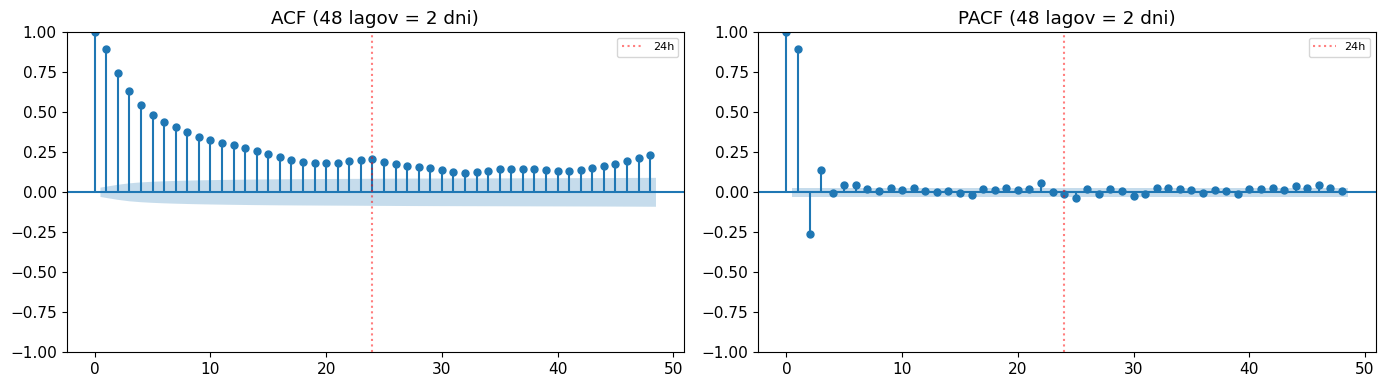

In [13]:
# ACF a PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=48, ax=axes[0], title='ACF (48 lagov = 2 dni)')
axes[0].axvline(24, color='red', linestyle=':', alpha=0.5, label='24h')
axes[0].legend(fontsize=8)

plot_pacf(y, lags=48, ax=axes[1], title='PACF (48 lagov = 2 dni)', method='ywm')
axes[1].axvline(24, color='red', linestyle=':', alpha=0.5, label='24h')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_IMG + '01_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Fáza 2: SARIMA modelovanie a predikcia

SARIMA  ukazuje, do akej miery sa dá glykémia predikovať z vlastnej histórie. V princípe s nejakou krátkodobou predikciou počítajú aj dnešné pumpy s uzavretým cyklom, lebo sa rozhodujú, aké množstvo inzulínu vydávkujú, aby glykémia o hodinu bola v rámci odporúčaných hodnôt.

Reziduá sú vstupom pre GARCH a diagnostiku štrukturálnych zlomov. Out-of-sample predikcia a porovnanie s naivným modelom ukazuje, či zložitejší model naozaj prináša pridanú hodnotu.

### 2.1 Test stacionarity

In [14]:
# ADF test (H0: rad je nestacionárny)
adf_result = adfuller(y, autolag='AIC')
print(f'  ADF štatistika: {adf_result[0]:.4f}')
print(f'  p-hodnota:      {adf_result[1]:.6f}')
print(f'  Počet lagov:    {adf_result[2]}')
for key, val in adf_result[4].items():
    print(f'  Kritická hodnota ({key}): {val:.4f}')

  ADF štatistika: -8.8851
  p-hodnota:      0.000000
  Počet lagov:    24
  Kritická hodnota (1%): -3.4318
  Kritická hodnota (5%): -2.8622
  Kritická hodnota (10%): -2.5671


zamietame H0, rad je stacionárny

In [15]:
# KPSS test (oH0: rad je stacionárny)
kpss_result = kpss(y, regression='c', nlags='auto')
print(f'  KPSS štatistika: {kpss_result[0]:.4f}')
print(f'  p-hodnota:       {kpss_result[1]:.4f}')
print(f'  Počet lagov:     {kpss_result[2]}')

  KPSS štatistika: 5.2886
  p-hodnota:       0.0100
  Počet lagov:     36


C:\Users\educa\AppData\Local\Temp\ipykernel_19728\455403169.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y, regression='c', nlags='auto')


zamietame H0, rad je nestacionárny

### 2.2 Fitovanie SARIMA modelov

Postupujeme od jednoduchých modelov ku komplexnejším. Na záver použijeme `auto_arima` pre automatický výber. (Ten trval dlho, takže vypustene)

In [16]:
# Definícia modelov na porovnanie
model_specs = {
    'AR(1)':                    {'order': (1,0,0), 'seasonal_order': (0,0,0,24)},
    'AR(2)':                    {'order': (2,0,0), 'seasonal_order': (0,0,0,24)},
    'SARIMA(1,0,0)(1,0,0)24':   {'order': (1,0,0), 'seasonal_order': (1,0,0,24)},
    'SARIMA(1,0,0)(0,0,1)24':   {'order': (1,0,0), 'seasonal_order': (0,0,1,24)},
    'SARIMA(1,0,0)(1,0,1)24':   {'order': (1,0,0), 'seasonal_order': (1,0,1,24)},
    'SARIMA(2,0,0)(1,0,1)24':   {'order': (2,0,0), 'seasonal_order': (1,0,1,24)},
}

In [17]:
results = {}
for name, spec in model_specs.items():
    print(f'Model {name}...', end=' ')
    try:
        model = SARIMAX(y, order=spec['order'], 
                        seasonal_order=spec['seasonal_order'],
                        trend='c', 
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False, maxiter=200)
        lb = acorr_ljungbox(res.resid, lags=[24], return_df=True)
        results[name] = {
            'model': res,
            'aic': res.aic,
            'bic': res.bic,
            'ljungbox_Q': lb['lb_stat'].values[0],
            'ljungbox_p': lb['lb_pvalue'].values[0],
        }
        print(f'AIC={res.aic:.1f}')
    except Exception as e:
        print(f'CHYBA: {e}')

Model AR(1)... AIC=16958.6
Model AR(2)... AIC=16639.8
Model SARIMA(1,0,0)(1,0,0)24... AIC=16851.5
Model SARIMA(1,0,0)(0,0,1)24... AIC=16853.5
Model SARIMA(1,0,0)(1,0,1)24... AIC=16762.7
Model SARIMA(2,0,0)(1,0,1)24... AIC=16461.4


In [18]:
# Namiesto auto_arima - manuálne rozšírenia najlepšieho modelu
extra_specs = {
    'SARIMA(2,0,1)(1,0,1)24': {'order': (2,0,1), 'seasonal_order': (1,0,1,24)},
    'SARIMA(2,0,2)(1,0,1)24': {'order': (2,0,2), 'seasonal_order': (1,0,1,24)},
    'SARIMA(1,0,1)(1,0,1)24': {'order': (1,0,1), 'seasonal_order': (1,0,1,24)},
}

for name, spec in extra_specs.items():
    print(f'Model {name}...', end=' ')
    try:
        model = SARIMAX(y, order=spec['order'], 
                        seasonal_order=spec['seasonal_order'],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False, maxiter=200)
        lb = acorr_ljungbox(res.resid, lags=[24], return_df=True)
        results[name] = {
            'model': res, 'aic': res.aic, 'bic': res.bic,
            'ljungbox_Q': lb['lb_stat'].values[0],
            'ljungbox_p': lb['lb_pvalue'].values[0],
        }
        print(f'AIC={res.aic:.1f}')
    except Exception as e:
        print(f'CHYBA: {e}')

Model SARIMA(2,0,1)(1,0,1)24... AIC=16411.9
Model SARIMA(2,0,2)(1,0,1)24... AIC=16401.4
Model SARIMA(1,0,1)(1,0,1)24... AIC=16412.6


In [19]:
# Súhrnná tabuľka modelov
comparison = pd.DataFrame({
    name: {'AIC': r['aic'], 'BIC': r['bic'], 
           'Ljung-Box Q(24)': r['ljungbox_Q'],
           'LB p-hodnota': r['ljungbox_p']}
    for name, r in results.items()
}).T.sort_values('AIC').round(2)

comparison

,AIC,BIC,Ljung-Box Q(24),LB p-hodnota
"SARIMA(2,0,2)(1,0,1)24",16401.42,16446.29,39.64,0.02
"SARIMA(2,0,1)(1,0,1)24",16411.89,16450.34,29.59,0.20
"SARIMA(1,0,1)(1,0,1)24",16412.59,16444.63,33.17,0.10
"SARIMA(2,0,0)(1,0,1)24",16461.41,16499.86,97.52,0.00
AR(2),16639.80,16665.46,147.10,0.00
"SARIMA(1,0,0)(1,0,1)24",16762.72,16794.77,336.10,0.00
"SARIMA(1,0,0)(1,0,0)24",16851.50,16877.13,383.67,0.00
"SARIMA(1,0,0)(0,0,1)24",16853.48,16879.11,384.76,0.00
AR(1),16958.55,16977.80,418.76,0.00


V podstate sa rozhodujeme medzi druhým a tretím modelom. Prvý má problém s autokoreláciou.
Druhý model (2,0,1) má nižšie AIC a zdá sa, že je toreticky lepšie obhájitelný. Avšak tretí model (1, 0, 1) sa v AIC líši len veľmi málo a BIC má nižší. Vzhľadom na parsimóniu možno preferovať práve tretí model.

Nesezónna AR(2) zložka modelu je klinicky interpretovateľná — glykemický „šok" spôsobený príjmom potravy alebo bolusovou dávkou inzulínu pôsobí spravidla 1–2 hodiny, čo zodpovedá signifikantným lagom 1 a 2 v hodinovom rade. AR(2) tak zachytáva krátkodobú farmakodynamickú pamäť.

### 2.3 Diagnostika najlepšieho modelu

In [20]:
# Model s najnižším AIC mal signifikantnú autokoreláciu reziduí (Ljung-Box p < 0.05)
# → vybraný druhý najlepší model, ktorý spĺňa diagnostické kritériá
best_name = 'SARIMA(2,0,1)(1,0,1)24'
best_model = results[best_name]['model']
print(f'Vybraný model: {best_name}')

Vybraný model: SARIMA(2,0,1)(1,0,1)24


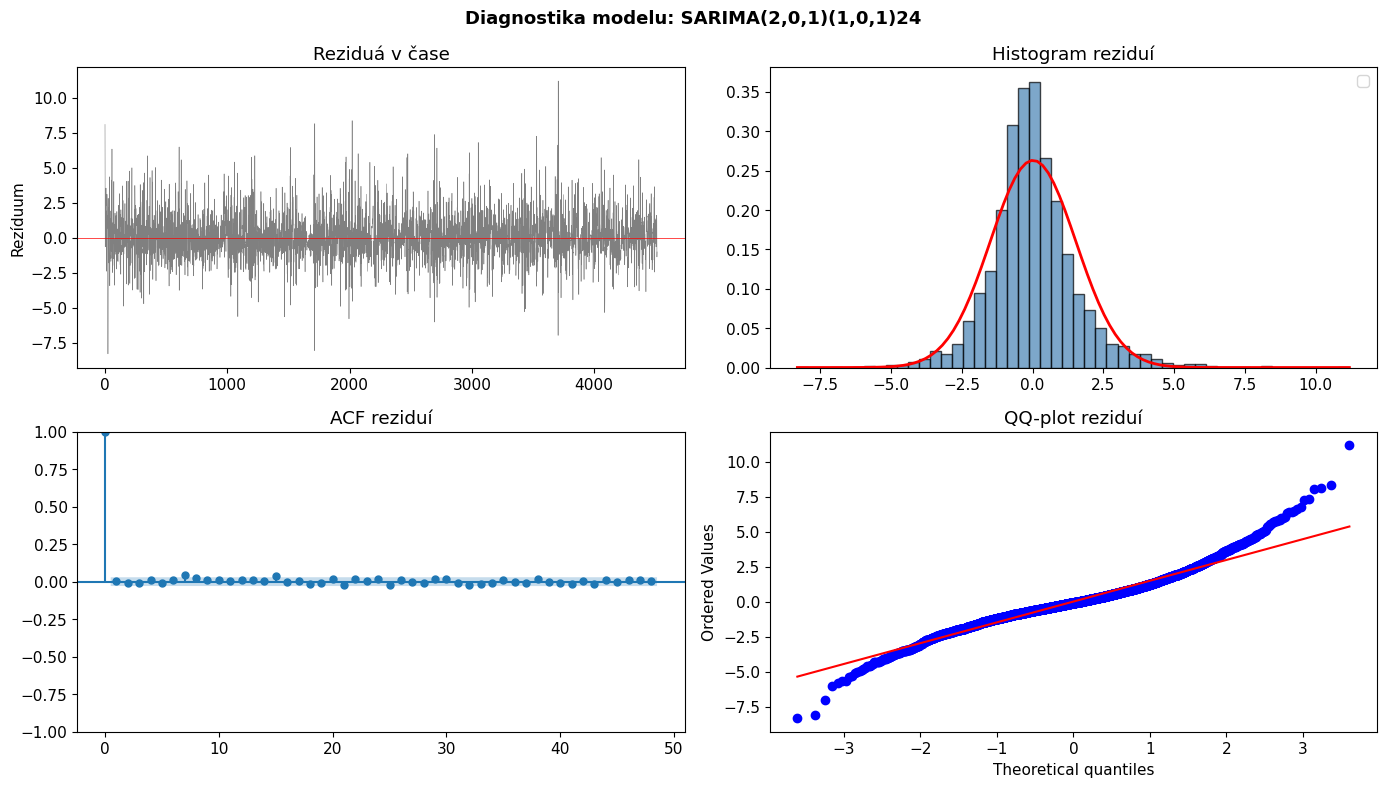

In [22]:
resid = best_model.resid

# Diagnostické grafy
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Reziduá v čase
axes[0,0].plot(resid, linewidth=0.4, color='gray')
axes[0,0].axhline(0, color='red', linestyle='-', lw=0.5)
axes[0,0].set_title('Reziduá v čase')
axes[0,0].set_ylabel('Rezíduum')

# Histogram reziduí
axes[0,1].hist(resid, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x_range = np.linspace(resid.min(), resid.max(), 100)
axes[0,1].plot(x_range, stats.norm.pdf(x_range, resid.mean(), resid.std()), 
               'r-', lw=2)
axes[0,1].set_title('Histogram reziduí')
axes[0,1].legend()

# ACF reziduí
plot_acf(resid, lags=48, ax=axes[1,0], title='ACF reziduí')

# QQ-plot
stats.probplot(resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ-plot reziduí')

plt.suptitle(f'Diagnostika modelu: {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_IMG + '02_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Diagnostické testy
# Ljung-Box test (H0: žiadna autokorelácia reziduí)
lb_result = acorr_ljungbox(resid, lags=[12, 24, 48], return_df=True)
lb_result

,lb_stat,lb_pvalue
12,15.063271,0.237995
24,29.587086,0.198816
48,47.457320,0.494983


Žiadna autokorelácia -> SARIMA model je adekvátny

In [24]:
# Jarque-Bera test (H0: normalita)
jb_stat, jb_p = stats.jarque_bera(resid)

print(f'  JB štatistika: {jb_stat:.2f}')
print(f'  p-hodnota:     {jb_p:.6f}')

  JB štatistika: 2278.92
  p-hodnota:     0.000000


Jarque-Bera	p ≈ 0	Nie normálne -> ťažké chvosty (extrémne hypo/hyper)

In [25]:
# ARCH-LM test (H0: žiadne ARCH efekty, heteroskedasticita)
arch_lm = het_arch(resid, nlags=12)

print(f'  LM štatistika: {arch_lm[0]:.2f}')
print(f'  p-hodnota:     {arch_lm[1]:.6f}')


  LM štatistika: 249.18
  p-hodnota:     0.000000


ARCH-LM	p ≈ 0	Silné ARCH efekty → volatilita sa mení v čase, potrebujeme GARCH

### 2.4 Out-of-sample predikcia

Porovnanie predikčnej výkonnosti SARIMA s naivnými benchmarkmi: či zložitejší model prináša pridanú hodnotu.

In [26]:
# Train/test split — posledných 7*2 dní (168*2 hodín) ako testovacia množina
TEST_SIZE = 168*2  # 7*2 dní
y_train = y[:-TEST_SIZE]
y_test = y[-TEST_SIZE:]
dates_test = dates[-TEST_SIZE:]

print(f'Tréningová množina: {len(y_train)} pozorovaní')
print(f'Testovacia množina: {len(y_test)} pozorovaní ({TEST_SIZE // 24} dní)')

Tréningová množina: 4179 pozorovaní
Testovacia množina: 336 pozorovaní (14 dní)


In [27]:
# Fitovanie najlepšieho modelu na tréningových dátach
best_spec = {
    'order': (2, 0, 1),
    'seasonal_order': (1, 0, 1, 24)
}

In [28]:
model_train = SARIMAX(y_train, 
                       order=best_spec['order'],
                       seasonal_order=best_spec['seasonal_order'],
                       trend='c',
                       enforce_stationarity=False,
                       enforce_invertibility=False)
res_train = model_train.fit(disp=False, maxiter=200)

In [29]:
# Predikcia na testovaciu množinu
forecast = res_train.forecast(steps=TEST_SIZE)

In [30]:
# Naivné benchmarky
# 1. Naivný model (lag 1): predikcia = posledná známa hodnota
naive_forecast = np.full(TEST_SIZE, y_train[-1])

In [31]:
# 2. Sezónny naivný model (lag 24): predikcia = hodnota pred 24h
seasonal_naive_forecast = y_train[-24:].tolist() * (TEST_SIZE // 24 + 1)
seasonal_naive_forecast = np.array(seasonal_naive_forecast[:TEST_SIZE])

In [32]:
# Metriky
def compute_metrics(actual, predicted, name):
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mae = np.mean(np.abs(actual - predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'MAPE (%)': round(mape, 2)}

In [33]:
metrics = pd.DataFrame([
    compute_metrics(y_test, forecast, best_name),
    compute_metrics(y_test, naive_forecast, 'Naivný (lag 1)'),
    compute_metrics(y_test, seasonal_naive_forecast, 'Sezónny naivný (lag 24)'),
]).set_index('Model')

print('=== Porovnanie predikčnej výkonnosti ===')
metrics

=== Porovnanie predikčnej výkonnosti ===


,RMSE,MAE,MAPE (%)
Model,,,
"SARIMA(2,0,1)(1,0,1)24",3.974,3.391,28.93
Naivný (lag 1),6.210,5.317,37.09
Sezónny naivný (lag 24),5.903,4.937,35.35


## 2.5 Rolling 24 h predikcia

In [34]:
# Rolling 24h predikcia
HORIZON = 24  # 1 deň
n_windows = TEST_SIZE // HORIZON  # 7 okien

sarima_errors = []
naive_errors = []
seasonal_errors = []

In [35]:

for i in range(n_windows):
    # Tréningové dáta sa posúvajú
    train_end = len(y) - TEST_SIZE + i * HORIZON
    y_tr = y[:train_end]
    y_te = y[train_end:train_end + HORIZON]
    
    # SARIMA predikcia
    model_roll = SARIMAX(y_tr, order=(2,0,1), seasonal_order=(1,0,1,24), trend = 'c',
                          enforce_stationarity=False, enforce_invertibility=False)
    res_roll = model_roll.fit(disp=False, maxiter=200)
    fc = res_roll.forecast(steps=HORIZON)
    
    # Naivné benchmarky
    naive_fc = np.full(HORIZON, y_tr[-1])
    seasonal_fc = y_tr[-24:]
    
    # Chyby
    sarima_errors.extend(y_te - fc)
    naive_errors.extend(y_te - naive_fc)
    seasonal_errors.extend(y_te - seasonal_fc)
    
    print(f'  Okno {i+1}/{n_windows}: RMSE={np.sqrt(np.mean((y_te - fc)**2)):.2f}')

  Okno 1/14: RMSE=3.97
  Okno 2/14: RMSE=3.90
  Okno 3/14: RMSE=3.43
  Okno 4/14: RMSE=4.90
  Okno 5/14: RMSE=2.20
  Okno 6/14: RMSE=3.23
  Okno 7/14: RMSE=2.90
  Okno 8/14: RMSE=2.69
  Okno 9/14: RMSE=4.38
  Okno 10/14: RMSE=2.85
  Okno 11/14: RMSE=4.05
  Okno 12/14: RMSE=4.97
  Okno 13/14: RMSE=2.39
  Okno 14/14: RMSE=2.61


In [36]:
# Celkové metriky
print(f'\n=== Rolling 24h predikcia ({n_windows} okien) ===')
for name, errors in [('SARIMA', sarima_errors), 
                      ('Naivný', naive_errors), 
                      ('Sezónny naivný', seasonal_errors)]:
    e = np.array(errors)
    print(f'{name:20s}  RMSE={np.sqrt(np.mean(e**2)):.3f}  MAE={np.mean(np.abs(e)):.3f}  '
          f'MAPE={np.mean(np.abs(e)/np.abs(np.array(y[-TEST_SIZE:])))*100:.2f}%')


=== Rolling 24h predikcia (14 okien) ===
SARIMA                RMSE=3.571  MAE=2.950  MAPE=25.41%
Naivný                RMSE=4.698  MAE=3.608  MAPE=29.43%
Sezónny naivný        RMSE=4.730  MAE=3.745  MAPE=32.05%


## 2.6 D-M test

In [37]:
# Diebold-Mariano test: je SARIMA signifikantne lepšia ako sezónny naivný?


def diebold_mariano_test(actual, pred1, pred2, h=1):
    """
    Diebold-Mariano test. H0: oba modely majú rovnakú presnosť.
    h: forecast horizont (24 = rolling 24h predikcia)
    """
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2  # rozdiel štvorcových chýb
    
    mean_d = np.mean(d)
    # Newey-West odhad rozptylu
    n = len(d)
    var_d = np.var(d, ddof=1)
    for k in range(1, h):
        gamma_k = np.mean((d[k:] - mean_d) * (d[:-k] - mean_d))
        var_d += 2 * gamma_k
    
    dm_stat = mean_d / np.sqrt(var_d / n)
    p_value = 2 * stats.norm.sf(abs(dm_stat))
    return dm_stat, p_value

# Rekonštrukcia predikcií z rolling chýb
actual = np.array(y[-TEST_SIZE:])
sarima_pred    = actual - np.array(sarima_errors)
seasonal_pred  = actual - np.array(seasonal_errors)
naive_pred     = actual - np.array(naive_errors)

# DM test: SARIMA vs Sezónny naivný
dm_stat_sn, dm_p_sn = diebold_mariano_test(actual, sarima_pred, seasonal_pred, h=24)

# DM test: SARIMA vs Naivný
dm_stat_n, dm_p_n = diebold_mariano_test(actual, sarima_pred, naive_pred, h=24)

print(f'=== Diebold-Mariano test ({best_name} vs. benchmarky) ===')
print(f'\nSARIMA vs. Sezónny naivný:')
print(f'  DM štatistika: {dm_stat_sn:.4f}')
print(f'  p-hodnota:     {dm_p_sn:.6f}')
print(f'  Záver: {"SARIMA je signifikantne lepšia (p < 0.05)" if dm_p_sn < 0.05 else "Rozdiel nie je signifikantný"}')

print(f'\nSARIMA vs. Naivný (lag 1):')
print(f'  DM štatistika: {dm_stat_n:.4f}')
print(f'  p-hodnota:     {dm_p_n:.6f}')
print(f'  Záver: {"SARIMA je signifikantne lepšia (p < 0.05)" if dm_p_n < 0.05 else "Rozdiel nie je signifikantný"}')

=== Diebold-Mariano test (SARIMA(2,0,1)(1,0,1)24 vs. benchmarky) ===

SARIMA vs. Sezónny naivný:
  DM štatistika: -3.0672
  p-hodnota:     0.002161
  Záver: SARIMA je signifikantne lepšia (p < 0.05)

SARIMA vs. Naivný (lag 1):
  DM štatistika: -1.7808
  p-hodnota:     0.074948
  Záver: Rozdiel nie je signifikantný


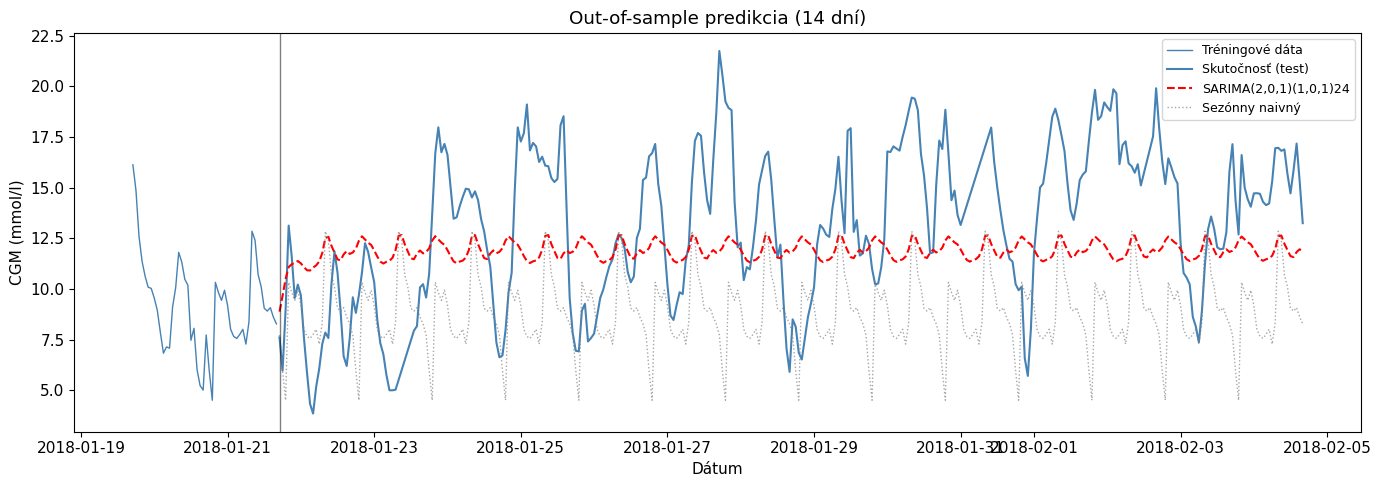

In [38]:
# Graf predikcie vs. skutočnosť
fig, ax = plt.subplots(figsize=(14, 5))

# Posledných 48h tréningových dát pre kontext
context = 48
ax.plot(dates[-(TEST_SIZE+context):-TEST_SIZE], y[-(TEST_SIZE+context):-TEST_SIZE], 
        color='steelblue', lw=1, label='Tréningové dáta')
ax.plot(dates_test, y_test, color='steelblue', lw=1.5, label='Skutočnosť (test)')
ax.plot(dates_test, forecast, color='red', lw=1.5, linestyle='--', label=f'{best_name}')
ax.plot(dates_test, seasonal_naive_forecast, color='gray', lw=1, linestyle=':', 
        alpha=0.7, label='Sezónny naivný')

ax.axvline(dates_test[0], color='black', lw=1, linestyle='-', alpha=0.5)
ax.set_xlabel('Dátum')
ax.set_ylabel('CGM (mmol/l)')
ax.set_title(f'Out-of-sample predikcia ({TEST_SIZE // 24} dní)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_IMG + '02_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Fáza 3: Štrukturálne zlomy

Paper uvádza plánované intervencie (úpravy parametrov pumpy) v týždňoch 2 a 13. Testujeme, či tieto zásahy spôsobili merateľný zlom v glykemickom rade. Ak áno -> intervencie mali efekt u tohto pacienta. Ak nie -> potvrdzuje to záver paperu, že celkovo TIR sa nezmenil.

### 3.1 Chow test

Testujeme stabilitu AR modelu v známych breakpointoch (T2, T13).

In [39]:
def chow_test(y, breakpoint_idx, lags=2):
    """
    Chow test pre štrukturálny zlom v AR modeli.
    H0: parametre modelu sú stabilné (žiadny zlom).
    """
    from statsmodels.tsa.ar_model import AutoReg
    
    n = len(y)
    k = lags + 1  # počet parametrov (vrátane interceptu)
    
    # Celý model
    model_full = AutoReg(y, lags=lags).fit()
    rss_full = np.sum(model_full.resid**2)
    
    # Podvzorky
    y1 = y[:breakpoint_idx]
    y2 = y[breakpoint_idx:]
    
    if len(y1) <= k or len(y2) <= k:
        return np.nan, np.nan
    
    model1 = AutoReg(y1, lags=lags).fit()
    model2 = AutoReg(y2, lags=lags).fit()
    
    rss1 = np.sum(model1.resid**2)
    rss2 = np.sum(model2.resid**2)
    
    F = ((rss_full - rss1 - rss2) / k) / ((rss1 + rss2) / (n - 2*k))
    p_value = 1 - stats.f.cdf(F, k, n - 2*k)
    
    return F, p_value

In [40]:
# Indexy breakpointov v hodinovom rade
idx_t2 = np.searchsorted(dates, np.datetime64(T2))
idx_t2

np.int64(322)

In [41]:
idx_t13 = np.searchsorted(dates, np.datetime64(T13))
idx_t13

np.int64(2002)

In [42]:
# Chow test v oboch breakpointoch (AR(2))
for bp_name, bp_idx in [('T2', idx_t2), ('T13', idx_t13)]:
    F, p = chow_test(y, bp_idx, lags=2)
    print(f'\n=== Chow test v {bp_name} (AR(2)) ===')
    print(f'  F-štatistika: {F:.4f}')
    print(f'  p-hodnota:    {p:.6f}')
    print(f'  Záver: {"ZAMIETAME H0 -> štrukturálny zlom" if p < 0.05 else "Nezamietame H0 -> nie je zlom"}')


=== Chow test v T2 (AR(2)) ===
  F-štatistika: 8.9772
  p-hodnota:    0.000006
  Záver: ZAMIETAME H0 -> štrukturálny zlom

=== Chow test v T13 (AR(2)) ===
  F-štatistika: 29.6742
  p-hodnota:    0.000000
  Záver: ZAMIETAME H0 -> štrukturálny zlom


### 3.2 CUSUM plot

In [43]:
# CUSUM — kumulatívne sumy rekurzívnych reziduí
from statsmodels.stats.diagnostic import OLS
from numpy.linalg import lstsq

In [44]:
# Zjednodušený CUSUM: kumulatívna suma štandardizovaných reziduí AR(1)
from statsmodels.tsa.ar_model import AutoReg
ar2 = AutoReg(y, lags=2).fit()
resid_ar2 = ar2.resid
std_resid = resid_ar2 / resid_ar2.std()
cusum = np.cumsum(std_resid) / np.sqrt(len(std_resid))

In [45]:
df_ar = pd.DataFrame({
    'y':      y[2:],
    'y_lag1': y[1:-1],
    'y_lag2': y[:-2]
})

X = sm.add_constant(df_ar[['y_lag1', 'y_lag2']])
rls = RecursiveLS(df_ar['y'], X).fit()

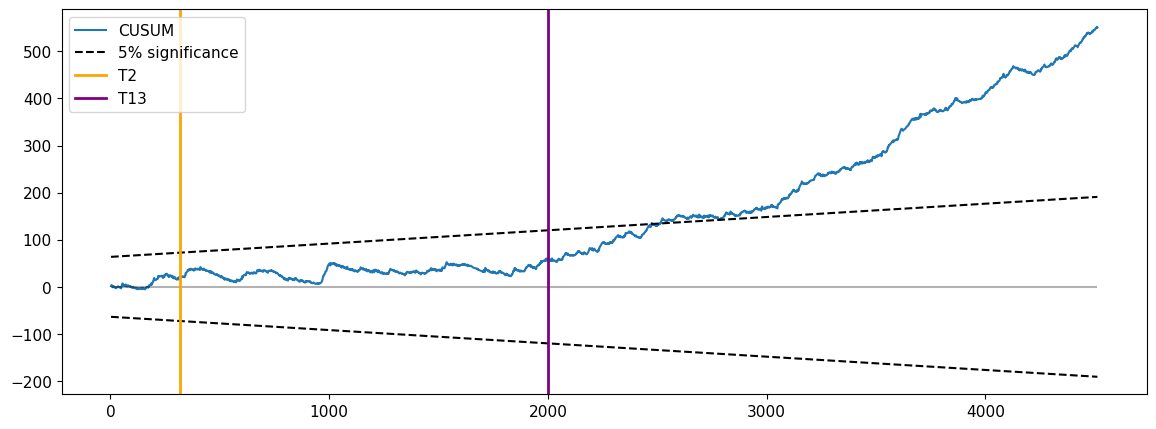

In [46]:
fig = rls.plot_cusum(alpha=0.05)
ax = fig.axes[0]
ax.axvline(idx_t2 - 2, color='orange', lw=2, label='T2')
ax.axvline(idx_t13 - 2, color='purple', lw=2, label='T13')
ax.legend()
plt.savefig(OUT_IMG + '03_cusum.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Porovnanie období

In [47]:
# Porovnanie metrík v 3 obdobiach
periods = {
    'Pred T2': y[:idx_t2],
    'T2 — T13': y[idx_t2:idx_t13],
    'Po T13': y[idx_t13:],
}

period_stats = []
for name, data in periods.items():
    data_mgdl = data * 18  # spätná konverzia pre TIR
    tir = np.mean((data_mgdl >= 70) & (data_mgdl <= 180)) * 100
    period_stats.append({
        'Obdobie': name,
        'N (hodín)': len(data),
        'Priemer (mmol/l)': round(data.mean(), 2),
        'SD (mmol/l)': round(data.std(), 2),
        'TIR (%)': round(tir, 1),
        'GMI (%)': round(3.31 + 0.02392 * data_mgdl.mean(), 2),
    })

period_df = pd.DataFrame(period_stats).set_index('Obdobie')
print('=== Porovnanie období ===')
period_df

=== Porovnanie období ===


,N (hodín),Priemer (mmol/l),SD (mmol/l),TIR (%),GMI (%)
Obdobie,,,,,
Pred T2,322,8.69,2.78,74.2,7.05
T2 — T13,1680,9.12,2.88,71.4,7.24
Po T13,2513,11.47,3.62,39.0,8.25


---

# Fáza 4: Modelovanie volatility — GARCH

Glykemická variabilita je samostatná klinická metrika. GARCH zachytáva, či sa volatilita mení v čase. Ak podmienená volatilita klesla po intervenciách, pumpa sa lepšie nastavila a glykémia sa stabilizovala — aj keď priemer sa nemusel výrazne zmeniť.

### 4.1 ARCH efekty v reziduách

In [59]:
# ARCH-LM test bol už spustený vo Fáze 2
arch_lm = het_arch(resid, nlags=12)
print(f'=== ARCH-LM test (12 lagov) ===')
print(f'  LM štatistika: {arch_lm[0]:.2f}')
print(f'  p-hodnota:     {arch_lm[1]:.6f}')

=== ARCH-LM test (12 lagov) ===
  LM štatistika: 249.18
  p-hodnota:     0.000000
  Záver: Prítomné ARCH efekty


 Záver: p < 0.05 => Prítomné ARCH efekty

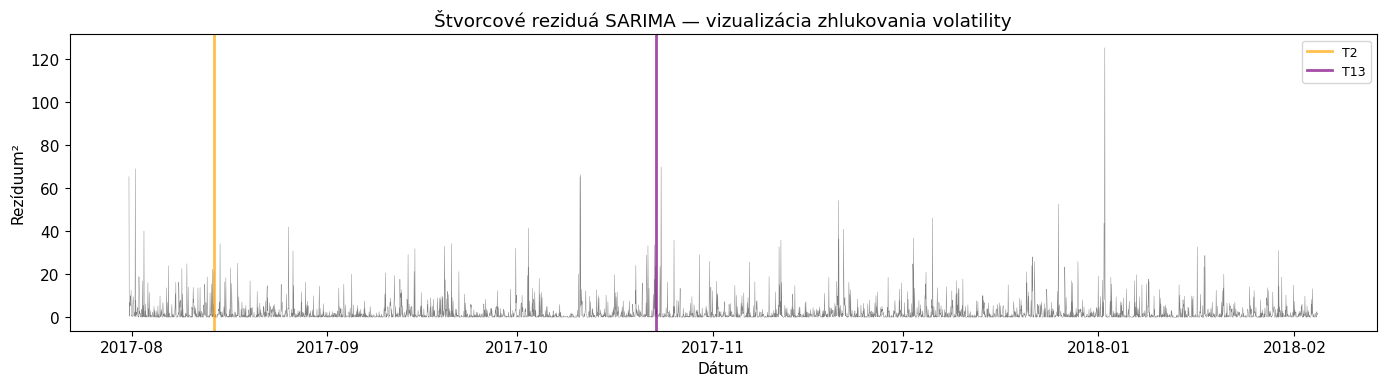

In [61]:
# Vizualizácia štvorcových reziduí
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, resid**2, linewidth=0.3, color='gray')
ax.axvline(T2, color='orange', lw=2, alpha=0.7, label='T2')
ax.axvline(T13, color='purple', lw=2, alpha=0.7, label='T13')
ax.set_xlabel('Dátum')
ax.set_ylabel('Rezíduum²')
ax.set_title('Štvorcové reziduá SARIMA — vizualizácia zhlukovania volatility')
ax.legend(fontsize=9)
plt.tight_layout()

plt.savefig(OUT_IMG + '03_rezidua_SARIMA.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 GARCH(1,1) model

In [51]:
# Fitovanie GARCH(1,1) na reziduá SARIMA modelu
# Škálujeme reziduá pre lepšiu konvergenciu
resid_scaled = resid * 100  # škálovanie

am = arch_model(resid_scaled, vol='Garch', p=1, q=1, mean='Zero')
garch_res = am.fit(disp='off')
print(garch_res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -28871.4
Distribution:                  Normal   AIC:                           57748.8
Method:            Maximum Likelihood   BIC:                           57768.1
                                        No. Observations:                 4515
Date:                Sat, Jun 20 2026   Df Residuals:                     4515
Time:                        17:15:37   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega       5801.8522    592.266      9.796  1.171e-22 [4.

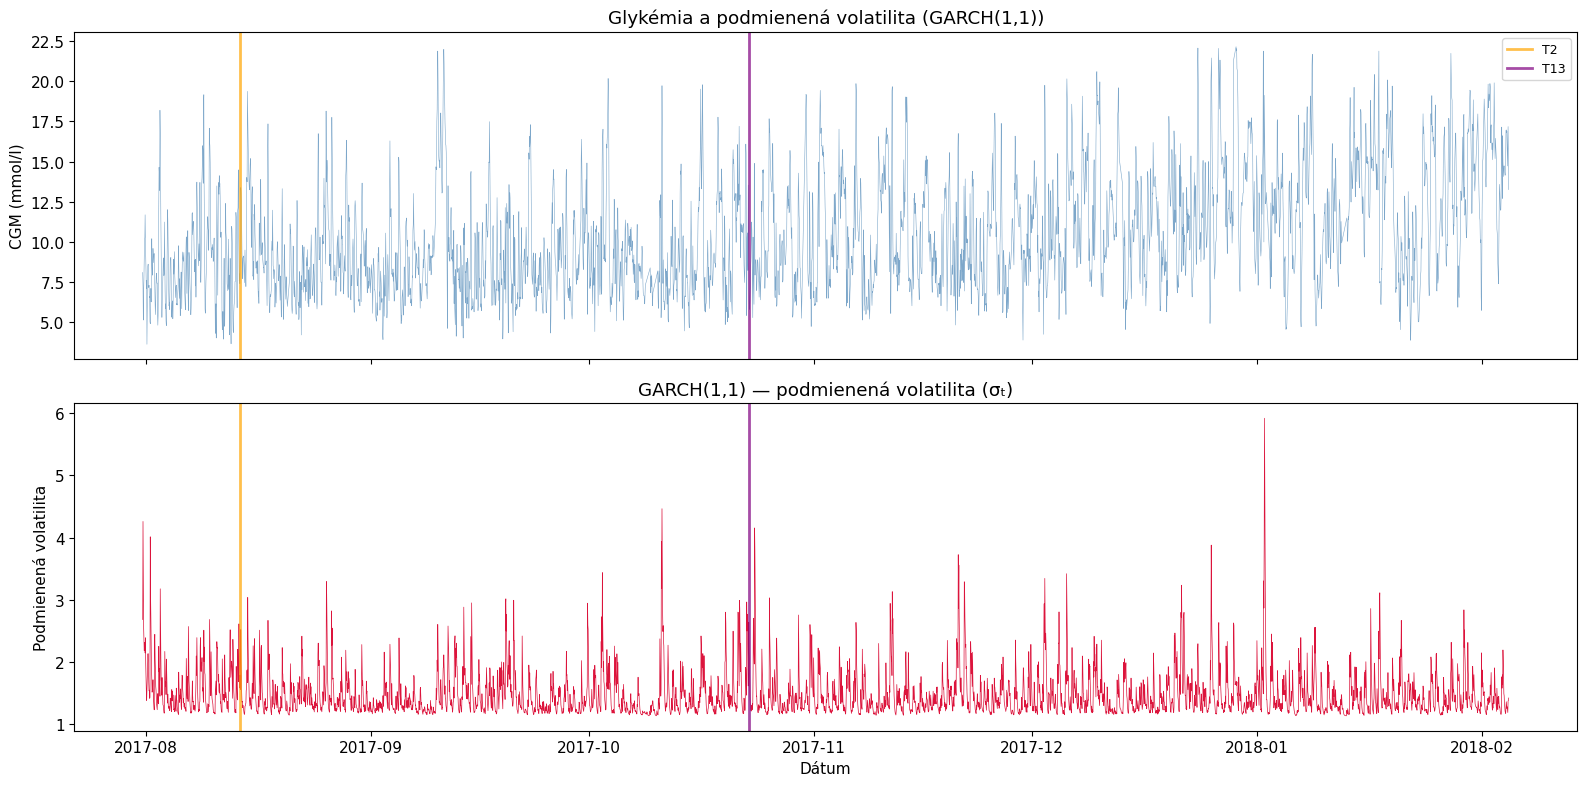


=== Priemerná podmienená volatilita podľa období ===
  Pred T2: 1.6127
  T2 — T13: 1.4648
  Po T13: 1.4785


In [67]:
# Podmienená volatilita v čase
cond_vol = garch_res.conditional_volatility / 100  # škálovanie späť

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Pôvodný rad
axes[0].plot(dates, y, linewidth=0.4, color='steelblue', alpha=0.7)
axes[0].axvline(T2, color='orange', lw=2, alpha=0.7, label='T2')
axes[0].axvline(T13, color='purple', lw=2, alpha=0.7, label='T13')
axes[0].set_ylabel('CGM (mmol/l)')
axes[0].set_title('Glykémia a podmienená volatilita (GARCH(1,1))')
axes[0].legend(fontsize=9)

# Podmienená volatilita
axes[1].plot(dates, cond_vol, linewidth=0.5, color='crimson')
axes[1].axvline(T2, color='orange', lw=2, alpha=0.7)
axes[1].axvline(T13, color='purple', lw=2, alpha=0.7)
axes[1].set_xlabel('Dátum')
axes[1].set_ylabel('Podmienená volatilita')
axes[1].set_title('GARCH(1,1) — podmienená volatilita (σₜ)')

plt.tight_layout()
plt.savefig(OUT_IMG + '04_garch_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

# Porovnanie priemernej volatility podľa období
vol_periods = {
    'Pred T2': cond_vol[:idx_t2].mean(),
    'T2 — T13': cond_vol[idx_t2:idx_t13].mean(),
    'Po T13': cond_vol[idx_t13:].mean(),
}
print('\n=== Priemerná podmienená volatilita podľa období ===')
for name, val in vol_periods.items():
    print(f'  {name}: {val:.4f}')

---

# Fáza 5: Grangerova kauzalita — deň vs. noc

Testujeme, či denná glykémia predikuje nočnú a naopak. Grangerova kauzalita formálne testuje, či minulé hodnoty jedného radu zlepšujú predikciu druhého.

### 5.1 Vytvorenie denných a nočných radov

In [58]:
# Rozdelenie na deň (6:00–21:59) a noc (22:00–5:59)
df['hour'] = df['date_hour'].dt.hour
df['date'] = df['date_hour'].dt.date
df['is_day'] = df['hour'].between(6, 21)  # True = deň, False = noc

# Nočné hodiny 00:00–05:59 priradíme k predchádzajúcemu dňu
df['night_date'] = df['date_hour'].apply(
    lambda x: (x - pd.Timedelta(days=1)).date() if x.hour < 6 else x.date()
)

# Deň: priemer hodín 6:00–21:59 podľa kalendárneho dňa (tu je to správne)
daily_day = df[df['is_day']].groupby('date')['CGM_mmol'].mean().rename('day_cgm')

# Noc: priemer hodín 22:00–05:59 podľa night_date (nie date!)
daily_night = df[~df['is_day']].groupby('night_date')['CGM_mmol'].mean().rename('night_cgm')

daily = pd.concat([daily_day, daily_night], axis=1).dropna()
print(f'Počet dní s kompletným denným aj nočným meraním: {len(daily)}')
daily.head(10)

Počet dní s kompletným denným aj nočným meraním: 188


,day_cgm,night_cgm
2017-07-31,8.013750,7.87125
2017-08-01,7.273750,8.83625
2017-08-02,8.050000,11.92625
2017-08-03,7.245000,8.98750
2017-08-04,6.978750,7.65625
2017-08-05,7.079375,8.21875
2017-08-06,7.883750,7.38500
2017-08-07,9.388125,10.66000
2017-08-08,11.260625,11.85875
2017-08-09,11.340000,9.93625


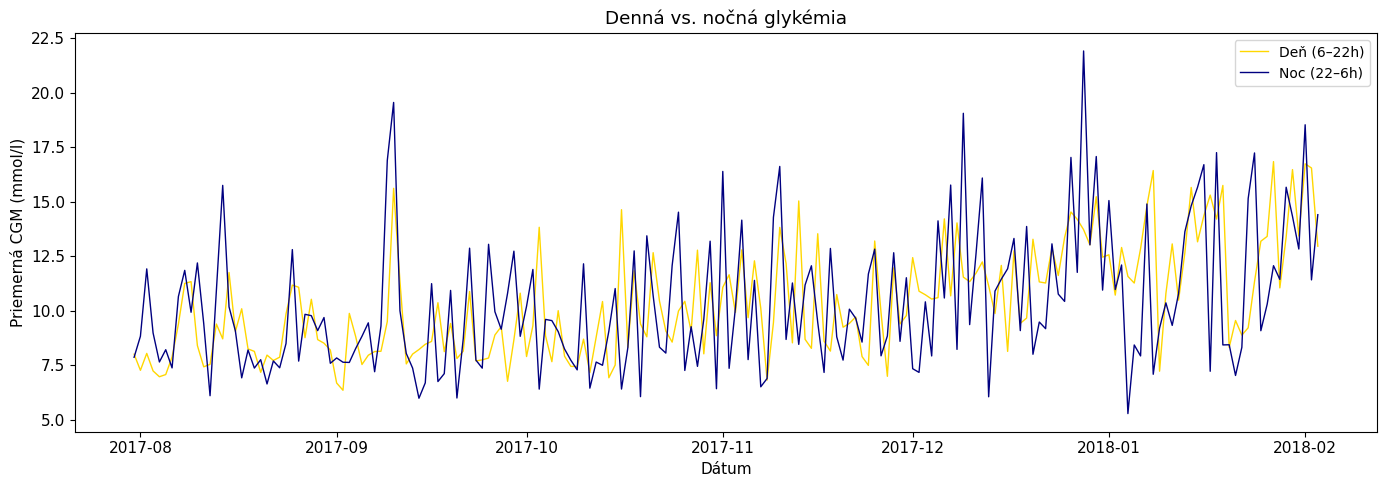

In [59]:
# Vizualizácia dennej a nočnej glykémie
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily['day_cgm'], label='Deň (6–22h)', color='gold', lw=1)
ax.plot(daily.index, daily['night_cgm'], label='Noc (22–6h)', color='navy', lw=1)
ax.set_xlabel('Dátum')
ax.set_ylabel('Priemerná CGM (mmol/l)')
ax.set_title('Denná vs. nočná glykémia')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_IMG + '05_day_night.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Stacionarita denných radov

In [70]:
# ADF test pre oba rady
for name, series in [('Deň', daily['day_cgm']), ('Noc', daily['night_cgm'])]:
    adf = adfuller(series, autolag='AIC')
    print(f'ADF test — {name}: štatistika={adf[0]:.4f}, p={adf[1]:.6f} → '
          f'{"Stacionárny" if adf[1] < 0.05 else "Nestacionárny"}')

ADF test — Deň: štatistika=-3.1766, p=0.021379 → Stacionárny
ADF test — Noc: štatistika=-6.5540, p=0.000000 → Stacionárny


### 5.3 VAR model a Grangerov test

In [71]:
# Výber optimálneho rádu VAR modelu
var_data = daily[['day_cgm', 'night_cgm']].values
var_model = VAR(var_data)

# Výber rádu podľa informačných kritérií
lag_order = var_model.select_order(maxlags=10)
print('=== Výber rádu VAR modelu ===')
print(lag_order.summary())

# Fitovanie VAR s optimálnym rádom
optimal_lag = lag_order.aic
print(f'\nOptimálny rád (AIC): {optimal_lag}')

var_result = var_model.fit(optimal_lag)
print(var_result.summary())

=== Výber rádu VAR modelu ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        3.243       3.278       25.61       3.257
1        2.992      3.099*       19.93       3.035
2        2.966       3.144       19.41       3.038
3       2.857*       3.106      17.41*      2.958*
4        2.889       3.209       17.98       3.019
5        2.908       3.300       18.33       3.067
6        2.932       3.395       18.78       3.120
7        2.886       3.420       17.93       3.102
8        2.915       3.521       18.48       3.161
9        2.938       3.614       18.90       3.212
10       2.918       3.666       18.55       3.221
--------------------------------------------------

Optimálny rád (AIC): 3
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 09, Jun, 2026
Time:                     14:25:13
------

In [72]:
# Grangerov test kauzality — oba smery
print('=== Grangerova kauzalita: Deň → Noc ===')
print('(H0: Denná glykémia ne-Granger-spôsobuje nočnú)')
gc_day_to_night = grangercausalitytests(daily[['night_cgm', 'day_cgm']].values, 
                                         maxlag=optimal_lag, verbose=True)
print()

print('=== Grangerova kauzalita: Noc → Deň ===')
print('(H0: Nočná glykémia ne-Granger-spôsobuje dennú)')
gc_night_to_day = grangercausalitytests(daily[['day_cgm', 'night_cgm']].values, 
                                         maxlag=optimal_lag, verbose=True)

=== Grangerova kauzalita: Deň → Noc ===
(H0: Denná glykémia ne-Granger-spôsobuje nočnú)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.9880  , p=0.0052  , df_denom=185, df_num=1
ssr based chi2 test:   chi2=8.1175  , p=0.0044  , df=1
likelihood ratio test: chi2=7.9471  , p=0.0048  , df=1
parameter F test:         F=7.9880  , p=0.0052  , df_denom=185, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.7212  , p=0.0261  , df_denom=182, df_num=2
ssr based chi2 test:   chi2=7.6469  , p=0.0219  , df=2
likelihood ratio test: chi2=7.4947  , p=0.0236  , df=2
parameter F test:         F=3.7212  , p=0.0261  , df_denom=182, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.8938  , p=0.0007  , df_denom=179, df_num=3
ssr based chi2 test:   chi2=18.3729 , p=0.0004  , df=3
likelihood ratio test: chi2=17.5211 , p=0.0006  , df=3
parameter F test:         F=5.8938  , p=0.0007  , df_denom=179, df_num=3

=== G

In [73]:
# Súhrnná tabuľka Grangerových testov
granger_summary = []
for lag in range(1, optimal_lag + 1):
    dn = gc_day_to_night[lag][0]
    nd = gc_night_to_day[lag][0]
    granger_summary.append({
        'Lag': lag,
        'Deň→Noc F': round(dn['ssr_ftest'][0], 3),
        'Deň→Noc p': round(dn['ssr_ftest'][1], 4),
        'Noc→Deň F': round(nd['ssr_ftest'][0], 3),
        'Noc→Deň p': round(nd['ssr_ftest'][1], 4),
    })

granger_df = pd.DataFrame(granger_summary).set_index('Lag')
print('=== Súhrnná tabuľka Grangerových testov ===')
granger_df

=== Súhrnná tabuľka Grangerových testov ===


,Deň→Noc F,Deň→Noc p,Noc→Deň F,Noc→Deň p
Lag,,,,
1,7.988,0.0052,1.192,0.2763
2,3.721,0.0261,0.306,0.7366
3,5.894,0.0007,1.202,0.3106


### 5.4 Interpretácia

**Dawn phenomenon** (Noc → Deň): Ak nočná glykémia Granger-spôsobuje dennú, naznačuje to, že nočné hormonálne procesy ovplyvňujú rannú glykémiu.

**Dusk phenomenon** (Deň → Noc): Ak denná glykémia Granger-spôsobuje nočnú, naznačuje to, že denné jedlo a aktivita ovplyvňujú nočný glykemický profil.